In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

VAL_PATH = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

MODEL_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Validation path:", VAL_PATH)
print("Model path:", MODEL_PATH)
print("Device:", device)

Validation path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\validation\images
Model path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth
Device: cpu


In [3]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_dataset = datasets.ImageFolder(
    VAL_PATH,
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

classes = val_dataset.classes

print("Classes:", classes)
print("Number of validation images:", len(val_dataset))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of validation images: 360


In [4]:
model = models.resnet18(weights=None)

num_classes = len(classes)

model.fc = torch.nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print("ResNet18 model created successfully!")

ResNet18 model created successfully!


In [7]:
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

model.eval()

print("Trained model loaded successfully!")

Trained model loaded successfully!


In [8]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions generated successfully!")
print("Total predictions:", len(all_predictions))

Predictions generated successfully!
Total predictions: 360


In [9]:
accuracy = np.mean(all_predictions == all_labels)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 1.0000
Validation Accuracy: 100.00%


In [10]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes
)

print(report)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



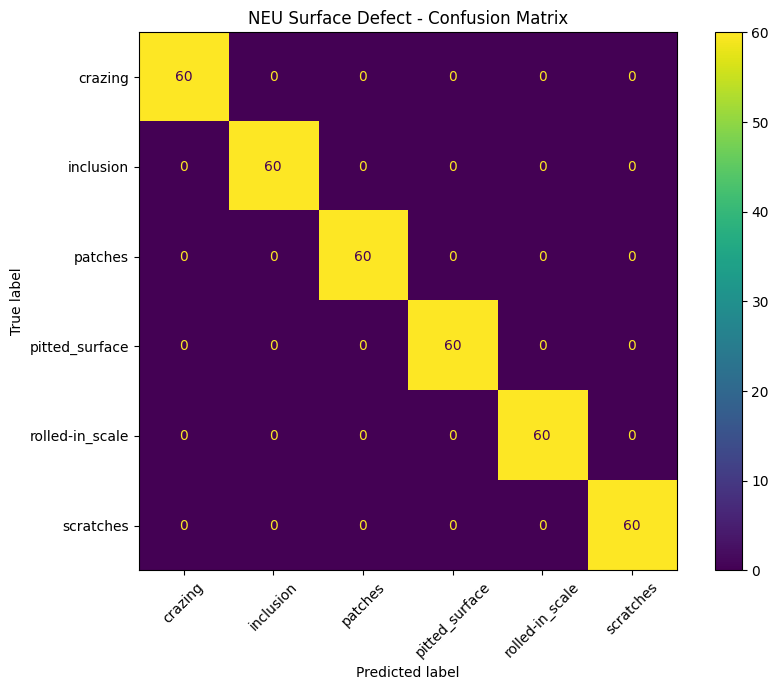

In [11]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("NEU Surface Defect - Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
wrong_indices = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect predictions:", len(wrong_indices))

Incorrect predictions: 0


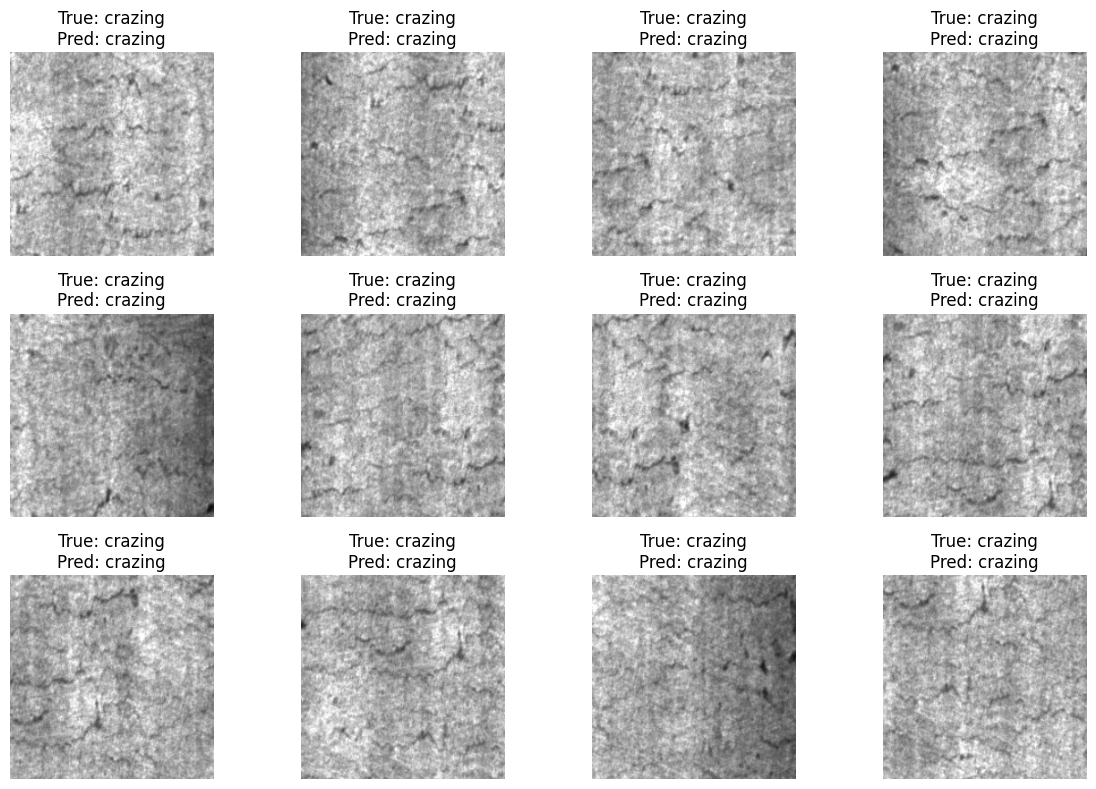

In [13]:
model.eval()

images, labels = next(iter(val_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = torch.argmax(outputs, dim=1)

predictions = predictions.cpu()

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):

    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    true_label = classes[labels[i]]
    predicted_label = classes[predictions[i]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
misclassified = []

for i in range(len(all_predictions)):
    if all_predictions[i] != all_labels[i]:
        misclassified.append(i)

print("Total validation images:", len(all_predictions))
print("Correct predictions:", len(all_predictions) - len(misclassified))
print("Misclassified images:", len(misclassified))

Total validation images: 360
Correct predictions: 360
Misclassified images: 0


In [15]:
model.eval()

confidence_scores = []
prediction_labels = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidence, predictions = torch.max(probabilities, dim=1)

        confidence_scores.extend(confidence.cpu().numpy())
        prediction_labels.extend(predictions.cpu().numpy())
        true_labels.extend(labels.numpy())

confidence_scores = np.array(confidence_scores)

print("Average confidence:",
      f"{confidence_scores.mean() * 100:.2f}%")

print("Minimum confidence:",
      f"{confidence_scores.min() * 100:.2f}%")

print("Maximum confidence:",
      f"{confidence_scores.max() * 100:.2f}%")

Average confidence: 99.69%
Minimum confidence: 52.89%
Maximum confidence: 100.00%


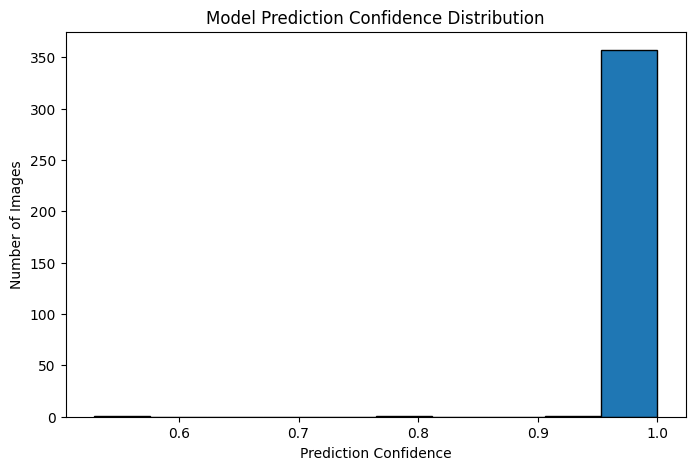

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(confidence_scores, bins=10, edgecolor="black")

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("Model Prediction Confidence Distribution")

plt.show()

In [20]:
# Correct Robustness Test
# Add small Gaussian noise to normalized images

model.eval()

correct = 0
total = 0

noise_level = 0.05

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Add small noise to normalized images
        noise = torch.randn_like(images) * noise_level
        noisy_images = images + noise

        # Do NOT clamp normalized images to 0-1

        outputs = model(noisy_images)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

robust_accuracy = correct / total

print("Robustness Test Accuracy:",
      f"{robust_accuracy * 100:.2f}%")

Robustness Test Accuracy: 99.44%


In [21]:
print("Original Validation Accuracy : 100.00%")
print(f"Noisy Image Accuracy         : {robust_accuracy * 100:.2f}%")
print(f"Accuracy Drop                : {(1 - robust_accuracy) * 100:.2f}%")

Original Validation Accuracy : 100.00%
Noisy Image Accuracy         : 99.44%
Accuracy Drop                : 0.56%
